Playing with ResNet-50


In [12]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt


# Reproducibility (optional)
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


# 1) Load CIFAR-10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
num_classes = 10

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# IMPORTANT:
# For tf.keras.applications.resnet.preprocess_input, keep pixels in 0..255
x_train = x_train.astype("float32")
x_test  = x_test.astype("float32")

# One-hot labels (to match your original setup)
y_train = to_categorical(y_train, num_classes=num_classes)
y_test  = to_categorical(y_test,  num_classes=num_classes)



In [13]:
# 2) Build Transfer Learning Model

IMG_SIZE = 224   # try 128 for faster training (change both input_shape and Resizing)
BATCH_SIZE = 64

base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


inputs = keras.Input(shape=(32, 32, 3))

# Resize CIFAR-10 images to ResNet input size
x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)

# Data augmentation (helps CIFAR-10)
x = layers.RandomFlip("horizontal")(x)
x = layers.RandomTranslation(0.1, 0.1)(x)
x = layers.RandomZoom(0.1)(x)

# ResNet preprocessing (expects 0..255 RGB)
x = tf.keras.applications.resnet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="cifar10_resnet50_transfer")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [15]:
from keras.backend import clear_session  # This is to clear any previous session to prevent reusing old data from  other cells etc.
clear_session()

In [18]:
# 3) Train Head (Frozen Backbone)

import time

base_model.trainable = False  # freeze backbone first

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print(model.summary())

start = time.time()
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=10,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)
end = time.time()

# display the fit time
total_time = end - start
print("Training time:", total_time, "seconds")



# Evaluate after head training
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
print(f"\nTest accuracy (frozen backbone): {test_acc:.4f}")

Model: "cifar10_resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 224, 224,  │          0 │ resizing[0][0]    │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation  │ (None, 224, 224,  │          0 │ random_flip[0][0] │
│ (RandomTranslation) │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 224, 224,  │          0 │ random_translati… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ random_zoom[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ random_zoom[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ random_zoom[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10)        │      1,290 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

None
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 192s 296ms/step - accuracy: 0.8603 - loss: 0.4125 - val_accuracy: 0.8891 - val_loss: 0.3168 - learning_rate: 0.0010
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 182s 292ms/step - accuracy: 0.8695 - loss: 0.3889 - val_accuracy: 0.8914 - val_loss: 0.3132 - learning_rate: 0.0010
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 182s 292ms/step - accuracy: 0.8762 - loss: 0.3661 - val_accuracy: 0.8965 - val_loss: 0.3003 - learning_rate: 0.0010
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 182s 292ms/step - accuracy: 0.8811 - loss: 0.3504 - val_accuracy: 0.9002 - val_loss: 0.2883 - learning_rate: 0.0010
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 182s 292ms/step - accuracy: 0.8899 - loss: 0.3343 - val_accuracy: 0.8992 - val_loss: 0.2873 - learning_rate: 0.0010
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 182s 292ms/step - accuracy: 0.8887 - loss: 0.3208 - val_accuracy: 0.9059 - val_loss: 0.2758 - learning_rate: 0.0010
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 182s 292ms/step - a

In [19]:
# display the accuracies for the train and validation sets
print(history.history.keys())

print("Train accuracy:", history.history["accuracy"][-1])
print("Validation accuracy:", history.history["val_accuracy"][-1])

# display the losses for the train and validation sets

print("Train loss:", history.history["loss"][-1])
print("Validation loss:", history.history["val_loss"][-1])

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])
Train accuracy: 0.8982250094413757
Validation accuracy: 0.910099983215332
Train loss: 0.3007841110229492
Validation loss: 0.26276519894599915


Test loss: 0.27486106753349304
Test accuracy: 0.9097999930381775
Validation accuracy: 0.27486106753349304
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step


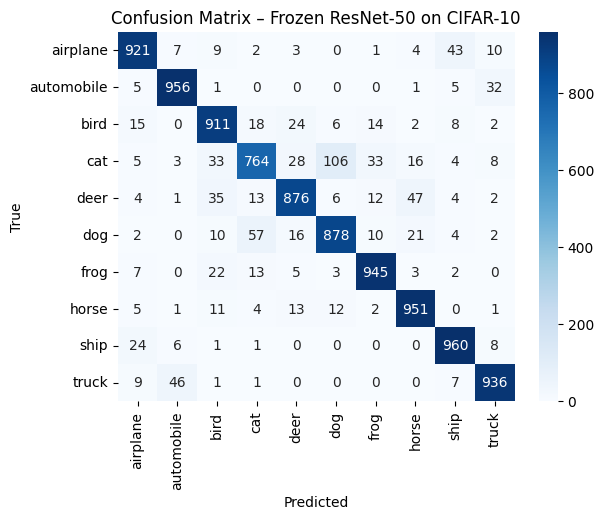

In [21]:
score = model.evaluate(x_test, y_test, verbose=0)

print("Test loss:", score[0])
print("Test accuracy:", score[1])
print("Validation accuracy:", score[0])

y_test_pred_prob = model.predict(x_test)
y_test_pred = y_test_pred_prob.argmax(axis=1)

conf_matr = confusion_matrix(np.argmax(y_test, axis=1), y_test_pred)

sns.heatmap(conf_matr, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Frozen ResNet-50 on CIFAR-10")
plt.show()

In [23]:
# 4) Fine-tuning (Unfreeze Top ResNet Stage)

# Unfreeze backbone
base_model.trainable = True

# Unfreeze only last stage conv5_ (safe default)
for layer in base_model.layers:
    layer.trainable = layer.name.startswith("conv5_")

# Keep BatchNorm frozen (helps stability on small datasets)
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Re-compile with a low LR
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
start = time.time()
history_ft = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=10,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)
end = time.time()

# display the fit time
total_time = end - start
print("Training time:", total_time, "seconds")


# Final evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
print(f"\nTest accuracy (fine-tuned): {test_acc:.4f}")


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 234s 359ms/step - accuracy: 0.9196 - loss: 0.2379 - val_accuracy: 0.9303 - val_loss: 0.2095 - learning_rate: 1.0000e-05
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 222s 355ms/step - accuracy: 0.9366 - loss: 0.1894 - val_accuracy: 0.9326 - val_loss: 0.2090 - learning_rate: 1.0000e-05
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 222s 355ms/step - accuracy: 0.9459 - loss: 0.1599 - val_accuracy: 0.9369 - val_loss: 0.2056 - learning_rate: 1.0000e-05
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 222s 355ms/step - accuracy: 0.9503 - loss: 0.1447 - val_accuracy: 0.9364 - val_loss: 0.2094 - learning_rate: 1.0000e-05
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 222s 355ms/step - accuracy: 0.9574 - loss: 0.1267 - val_accuracy: 0.9406 - val_loss: 0.1990 - learning_rate: 1.0000e-05
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 222s 355ms/step - accuracy: 0.9610 - loss: 0.1123 - val_accuracy: 0.9397 - val_loss: 0.2064 - learning_rate: 1.0000e-05
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 

Test loss: 0.20628590881824493
Test accuracy: 0.9354000091552734
Validation accuracy: 0.20628590881824493
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step


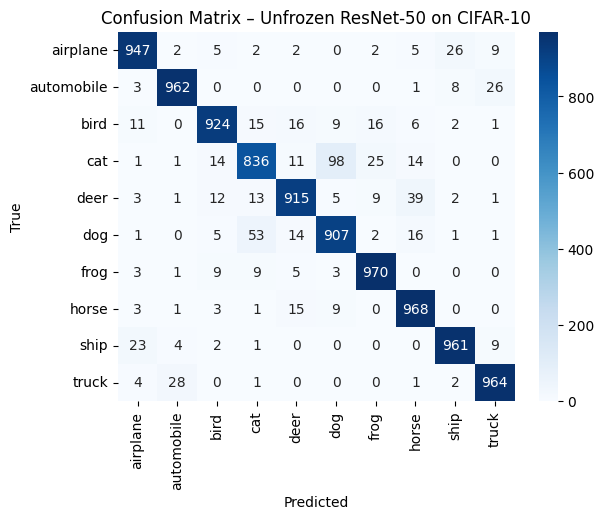

In [25]:
score = model.evaluate(x_test, y_test, verbose=0)

print("Test loss:", score[0])
print("Test accuracy:", score[1])
print("Validation accuracy:", score[0])

y_test_pred_prob = model.predict(x_test)
y_test_pred = y_test_pred_prob.argmax(axis=1)

conf_matr = confusion_matrix(np.argmax(y_test, axis=1), y_test_pred)

sns.heatmap(conf_matr, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Unfrozen ResNet-50 on CIFAR-10")
plt.show()

In [27]:
# 5) Fine-tuning (Unfreeze all ResNet-50 model)

# Unfreeze backbone
base_model.trainable = True

# Unfreeze all layers
for layer in base_model.layers:
    layer.trainable = True

# Keep BatchNorm frozen (helps stability on small datasets)
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Re-compile with a low LR
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
start = time.time()
history_ft = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=10,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)
end = time.time()

# display the fit time
total_time = end - start
print("Training time:", total_time, "seconds")


# Final evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
print(f"\nTest accuracy (finest-tuned): {test_acc:.4f}")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 428s 653ms/step - accuracy: 0.9593 - loss: 0.1217 - val_accuracy: 0.9443 - val_loss: 0.1863 - learning_rate: 1.0000e-05
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 405s 648ms/step - accuracy: 0.9682 - loss: 0.0980 - val_accuracy: 0.9451 - val_loss: 0.1986 - learning_rate: 1.0000e-05
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.9722 - loss: 0.0836
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
625/625 ━━━━━━━━━━━━━━━━━━━━ 405s 648ms/step - accuracy: 0.9722 - loss: 0.0836 - val_accuracy: 0.9409 - val_loss: 0.2254 - learning_rate: 1.0000e-05
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 405s 648ms/step - accuracy: 0.9798 - loss: 0.0589 - val_accuracy: 0.9570 - val_loss: 0.1760 - learning_rate: 5.0000e-06
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 405s 648ms/step - accuracy: 0.9836 - loss: 0.0477 - val_accuracy: 0.9527 - val_loss: 0.1900 - learning_rate: 5.0000e-06
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 405s 64

Test loss: 0.16453778743743896
Test accuracy: 0.9564999938011169
Validation accuracy: 0.16453778743743896
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step


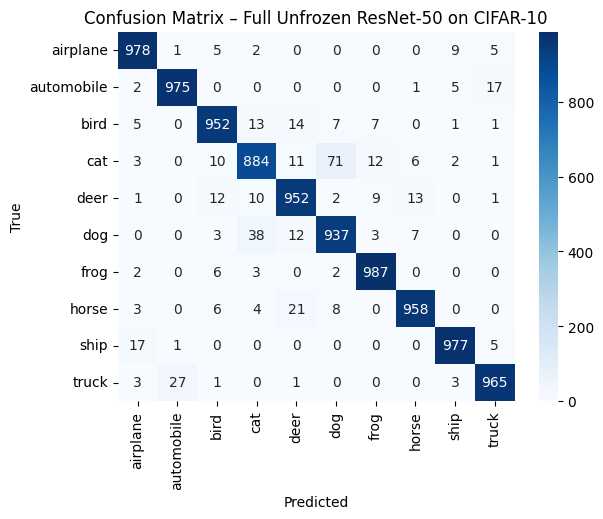

In [30]:
score = model.evaluate(x_test, y_test, verbose=0)

print("Test loss:", score[0])
print("Test accuracy:", score[1])
print("Validation accuracy:", score[0])

y_test_pred_prob = model.predict(x_test)
y_test_pred = y_test_pred_prob.argmax(axis=1)

conf_matr = confusion_matrix(np.argmax(y_test, axis=1), y_test_pred)

sns.heatmap(conf_matr, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Full Unfrozen ResNet-50 on CIFAR-10")
plt.show()

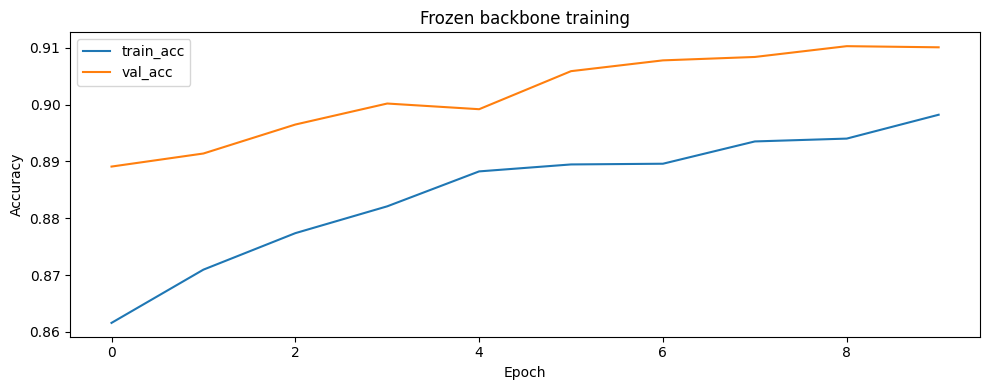

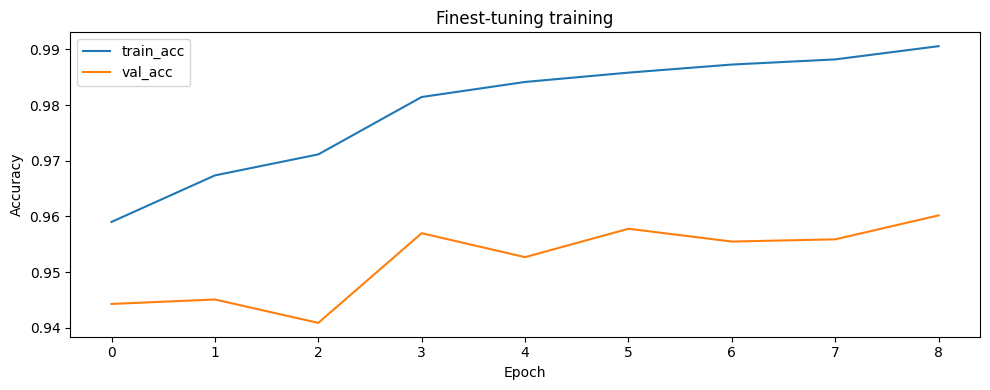

In [31]:
# 6) Plot training curves
# -----------------------
def plot_history(hist, title):
    plt.figure(figsize=(10, 4))
    plt.plot(hist.history.get("accuracy", []), label="train_acc")
    plt.plot(hist.history.get("val_accuracy", []), label="val_acc")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history, "Frozen backbone training")
plot_history(history_ft, "Finest-tuning training")